In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
df = pd.read_csv('cars_details_merges.csv')

/tmp/ipykernel_12062/999506015.py:1: DtypeWarning: Columns (25,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cars_details_merges.csv')


In [ ]:
df.shape

(37814, 140)

In [ ]:
df.head()

,position,loc,myear,bt,tt,ft,km,ip,pi,images,...,owner_type,price_segment_new,template_name_new,page_template,template_Type_new,experiment,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen
0,1,Gomti Nagar,2016,Hatchback,Manual,CNG,"69,162",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,first,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,NaN,NaN,NaN,NaN
1,2,Borivali West,2015,Hatchback,Manual,CNG,"45,864",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,first,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,Intelligent-Gas Port Injection,11.0:1,NaN,NaN
2,3,JASOLA,2015,Sedan,Manual,CNG,"81,506",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,second,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,NaN,NaN,NaN,NaN
3,4,jasola,2013,Hatchback,Manual,CNG,"1,15,893",0,NaN,[{'img': ''}],...,second,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,MPFI,NaN,13,NaN
4,5,mumbai g.p.o.,2022,MUV,Manual,CNG,"18,900",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,first,10+lakh,used cardetail v2,Used Car > Detail Page,used,control,NaN,12.0+-.03,NaN,NaN


In [ ]:
# cols to remove
# ip, pi, images, imgCount, dvn, oem, modelId, vid, centralVariantId, city_x, vlink, price, discountValue, msp, priceSaving,
# pageNo, utype, views, usedCarId, usedCarSkuId, ucid, sid, tmGaadiStore, dynx_itemid_x, dynx_itemid2_x, dynx_totalvalue_x,
# leadForm, leadFromCta, offers, compare, brandingIcon, pageType, carType, corporateId, Value Configuration, BoreX Stroke,
# model_type_new, originalLocation, page_title, compare_car_details, seller_type_new, seating_capacity_new, model_year_new,
# car_type_new, model_id_new, oem_name, dealer_id_new, city_id_new, max_engine_capacity_new, model_new, vehicle_type_new,
# engine_cc, fuel_type_new, car_segment, used_carid, city_name_new, page_type, city_y, engine_capaciity_new, body_type_new, dealer_id,
# model_year, variant_name, price_segment, dynx_event, dynx_pagetype, dynx_itemid_y, dynx_itemid2_y, dynx_totalvalue_y, brand_new,
# variant_new, exterior_color, min_engine_capaciity_new, owner_type, price_segment_new, template_name_new, page_template, template_Type_new, experiment, Compression Ratio



# transmissionType and tt and transmission_type and transmission_type_new me null values check krke ek hata dena
# fuel_type and ft me bhi null values check krna
# displacement and max_engine_capacity_new me bhi null values check krna
# top_features, comfortable_features, interior_features, exterior_features, safety_features --> may be merge them pr we can plot different word clouds for them to represent them separately

In [ ]:
df['transmissionType'].isnull().sum()

np.int64(0)

In [ ]:
df['tt'].isnull().sum()

np.int64(0)

In [ ]:
df['fuel_type'].isnull().sum()

np.int64(0)

In [ ]:
df['Displacement'].isnull().sum()

np.int64(53)

In [ ]:
df['max_engine_capacity_new'].isnull().sum()

np.int64(53)

In [ ]:
df['variant_new'].sample(10)

,variant_new
289,maruti eeco cng 5 seater ac
20435,maruti swift dzire lxi 1.2
24557,maruti ignis sigma
4309,renault kiger rxz
247,maruti eeco 5 str with ac plus htr cng
4350,renault duster 85ps diesel rxl option
29619,honda amaze s i-dtech
2904,toyota corolla altis g
9477,bmw x1 sdrive20i sportx
35693,honda city i dtec sv


In [ ]:
df = df.drop(columns = ['position', 'ip', 'pi', 'km', 'tt', 'images', 'imgCount', 'dvn', 'oem', 'modelId', 'vid', 'centralVariantId', 'city_x', 'vlink', 'price', 'discountValue', 'msp', 'priceSaving',
'pageNo', 'utype', 'views', 'usedCarId', 'usedCarSkuId', 'ucid', 'sid', 'tmGaadiStore', 'dynx_itemid_x', 'dynx_itemid2_x', 'dynx_totalvalue_x',
'leadForm', 'leadFormCta', 'offers', 'compare', 'brandingIcon', 'pageType', 'carType', 'corporateId', 'Value Configuration', 'BoreX Stroke',
'model_type_new', 'originalLocation', 'page_title', 'compare_car_details', 'seller_type_new', 'seating_capacity_new', 'model_year_new',
'car_type_new', 'model_id_new', 'oem_name', 'dealer_id_new', 'city_id_new', 'max_engine_capacity_new', 'model_new', 'vehicle_type_new',
'engine_cc', 'fuel_type_new', 'car_segment', 'used_carid', 'city_name_new', 'page_type', 'city_y', 'engine_capacity_new', 'body_type_new', 'dealer_id',
'model_year', 'variant_name', 'price_segment', 'dynx_event', 'dynx_pagetype', 'dynx_itemid_y', 'dynx_itemid2_y', 'dynx_totalvalue_y', 'brand_new',
'variantName', 'exterior_color', 'min_engine_capacity_new', 'owner_type', 'price_segment_new', 'template_name_new', 'page_template', 'template_Type_new',
'experiment', 'Compression Ratio', 'transmission_type_new', 'ft', 'max_engine_capacity_new', 'model'])

In [ ]:
df.head()

,loc,myear,bt,threesixty,pu,emiwidget,transmissionType,top_features,comfort_features,interior_features,...,state,fuel_type,km_driven,brand_name,owner_type_new,mileage_new,variant_new,Fuel Suppy System,Alloy Wheel Size,Ground Clearance Unladen
0,Gomti Nagar,2016,Hatchback,False,"3,70,000","{'title': 'EMI starts', 'cost': '9,184', 'dura...",Manual,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Rem...","['Air Conditioner', 'Heater', 'Digital Odomete...",...,uttar pradesh,cng,69162,maruti,first,26.6 kmpl,maruti wagon r lxi cng,NaN,NaN,NaN
1,Borivali West,2015,Hatchback,False,"3,65,000","{'title': 'EMI starts', 'cost': '9,060', 'dura...",Manual,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Pow...","['Air Conditioner', 'Heater', 'Digital Odomete...",...,maharashtra,cng,45864,maruti,first,31.79 kmpl,maruti celerio green vxi,Intelligent-Gas Port Injection,NaN,NaN
2,JASOLA,2015,Sedan,False,"4,21,000","{'title': 'EMI starts', 'cost': '10,450', 'dur...",Manual,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Pow...","['Air Conditioner', 'Heater', 'Adjustable Stee...",...,delhi,cng,81506,honda,second,18 kmpl,honda amaze s plus i-vtec,NaN,NaN,NaN
3,jasola,2013,Hatchback,False,"2,40,000","{'title': 'EMI starts', 'cost': '10,422', 'dur...",Manual,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Low...","['Air Conditioner', 'Heater', 'Electronic Mult...",...,delhi,cng,115893,maruti,second,26.2 kmpl,maruti wagon r lxi cng,MPFI,13,NaN
4,mumbai g.p.o.,2022,MUV,False,"11,75,000","{'title': 'EMI starts', 'cost': '29,164', 'dur...",Manual,"['Power Steering', 'Power Windows Front', 'Air...","['Power Steering', 'Power Windows Front', 'Pow...","['Air Conditioner', 'Heater', 'Adjustable Stee...",...,maharashtra,cng,18900,maruti,first,26.11 km/kg,maruti ertiga vxi cng,NaN,NaN,NaN


In [ ]:
df.columns

Index(['loc', 'myear', 'bt', 'threesixty', 'pu', 'emiwidget',
       'transmissionType', 'top_features', 'comfort_features',
       'interior_features', 'exterior_features', 'safety_features', 'Color',
       'Engine Type', 'Displacement', 'Max Power', 'Max Torque',
       'No of Cylinder', 'Values per Cylinder', 'Turbo Charger',
       'Super Charger', 'Length', 'Width', 'Height', 'Wheel Base',
       'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight', 'Gear Box',
       'Drive Type', 'Seating Capacity', 'Steering Type', 'Turning Radius',
       'Front Brake Type', 'Rear Brake Type', 'Top Speed', 'Acceleration',
       'Tyre Type', 'No Door Numbers', 'Cargo Volumn', 'transmission_type',
       'model_name', 'price_range_segment', 'state', 'fuel_type', 'km_driven',
       'brand_name', 'owner_type_new', 'mileage_new', 'variant_new',
       'Fuel Suppy System', 'Alloy Wheel Size', 'Ground Clearance Unladen'],
      dtype='object')

In [ ]:
# loc -> city, bt -> body_type, pu -> price, Color -> color, Engine Type -> engine_type, Displacement -> displacement,
# Max Power -> max_power, Max Torque -> max_torque, No of Cyylinder -> no_of_cylinders, Values per Cylinder -> valves_per_cylinder,
# Turbo Charger -> turb_charger, Super Charger -> super_charger, Length -> length, Width -> width

In [ ]:
df = df.drop(columns = ['transmissionType'])

In [ ]:
df = df.rename(columns = {'loc':'city', 'bt' : 'body_type', 'pu' : 'price', 'Color' : 'color', 'Engine Type' : 'engine_type', 'Displacement' : 'displacement',
           'Max Power' : 'max_power', 'Max Torque' : 'max_torque', 'No of Cylinder' : 'no_of_cylinders', 'Values per Cylinder' : 'valves_per_cylinder',
           'Turbo Charger' : 'turbo charger', 'Super Charger' : 'super_charger', 'Length' : 'length', 'Width' : 'width', 'Height' : 'height',
           'Wheel Base' : 'wheel_base', 'Front Tread' : 'front_tread', 'Rear Tread' : 'rear_tread', 'Kerb Weight' : 'kerb_weight', 'Gross Weight' : 'gross_weight',
           'Gear Box': 'gear_box', 'Drive Type' :'drive_type', 'Seating Capacity' : 'seating_capacity', 'Steering Type' : 'steering_type', 'Turning Radius' : 'turning_radius',
           'Front Brake Type' :'front_brake_type', 'Rear Brake Type' : 'rear_brake_type', 'Top Speed': 'top_speed', 'Acceleration' : 'acceleration',
           'Tyre Type' : 'tyre_type', 'No Door Numbers' : 'no_of_doors', 'Cargo Volumn' : 'cargo_volume', 'Fuel Suppy System' : 'fuel_supply_system',
           'Alloy Wheel Size' : 'alloy_wheel_size', 'mileage_new' : 'mileage', 'variant_new' : 'variant',
           'owner_type_new' : 'owner_type', 'model_name' : 'model', 'brand_name' : 'brand'})

In [ ]:
df = df.rename(columns = {'Ground Clearance Unladen' : 'ground_clearance_unladen'})

In [ ]:
df.columns

Index(['city', 'myear', 'body_type', 'threesixty', 'price', 'emiwidget',
       'top_features', 'comfort_features', 'interior_features',
       'exterior_features', 'safety_features', 'color', 'engine_type',
       'displacement', 'max_power', 'max_torque', 'no_of_cylinders',
       'valves_per_cylinder', 'turbo charger', 'super_charger', 'length',
       'width', 'height', 'wheel_base', 'front_tread', 'rear_tread',
       'kerb_weight', 'gross_weight', 'gear_box', 'drive_type',
       'seating_capacity', 'steering_type', 'turning_radius',
       'front_brake_type', 'rear_brake_type', 'top_speed', 'acceleration',
       'tyre_type', 'no_of_doors', 'cargo_volume', 'transmission_type',
       'model', 'price_range_segment', 'state', 'fuel_type', 'km_driven',
       'brand', 'owner_type', 'mileage', 'variant', 'fuel_supply_system',
       'alloy_wheel_size', 'ground_clearance_unladen'],
      dtype='object')

In [ ]:
df.to_csv('cleaned_cars_merges.csv', index = False)

In [ ]:
df['variant'].sample(10)

,variant
11986,mg astor sharp
25446,hyundai grand i10 1.2 kappa sportz bsiv
26853,maruti swift dzire vxi optional
21836,toyota glanza e
19254,hyundai i20 sportz option 1.2
23897,maruti swift dzire 1.2 lxi bsiv
31764,honda amaze s petrol
4532,ford figo 1.5d titanium plus mt
28841,hyundai i20 1.4 crdi sportz
33952,hyundai verna 1.6 sx vtvt


In [ ]:
df['safety_features'][0]

"['Centeral Locking', 'Child Safety Locks', 'Day Night Rear View Mirror', 'Passenger Side Rear View Mirror', 'Halogen Headlamps', 'Rear Seat Belts', 'Seat Belt Warning', 'Side Impact Beams', 'Front Impact Beams', 'Adjustable Seats', 'Centrally Mounted Fuel Tank', 'Engine Immobilizer', 'Engine Check Warning', 'Anti Theft Device']"

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

In [ ]:
def generate_wordcloud(df, column_name, title):

    # 1. Combine text
    text = ' '.join(df[column_name].fillna('').astype(str)).lower()

    # 2. Remove special characters
    text = re.sub(r"[^\w\s]", "", text)

    # 3. Standardize phrases
    replacements = {
        "air conditioner": "air_conditioner",
        "power steering": "power_steering",
        "seat belt": "seat_belt",
        "central locking": "central_locking",
        "engine immobilizer": "engine_immobilizer",
        "child safety": "child_safety",
        "cup holders": "cup_holders",
        "keyless entry": "keyless_entry",
        "power windows": "power_windows",
        "rear ac vents": "rear_ac_vents",
        "air bag": "airbag",
        "airbags": "airbag",
        "anti theft": "anti_theft",
        "impact beams": "impact_beams",
        "door lock": "door_lock"
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    # 4. Remove useless words (SAFE WAY)
    stopwords = [
        'rear', 'front', 'left', 'right', 'side',
        'passenger', 'driver', 'seat', 'head',
        'adjustable', 'mounted', 'mirror',
        'light', 'lights', 'device','warning'
    ]

    words = text.split()
    words = [w for w in words if w not in stopwords]
    text = ' '.join(words)

    # 5. Clean spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Generate wordcloud
    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=40,
        colormap='viridis',
        collocations=False
    ).generate(text)

    # 7. Plot WordCloud
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

    # 8. Top features bar chart
    word_counts = Counter(text.split())
    top = word_counts.most_common(10)

    top_df = pd.DataFrame(top, columns=['Feature', 'Count'])

    plt.figure(figsize=(8,4))
    plt.bar(top_df['Feature'], top_df['Count'])
    plt.xticks(rotation=45)
    plt.title(f"Top Features - {title}")
    plt.tight_layout()
    plt.show()

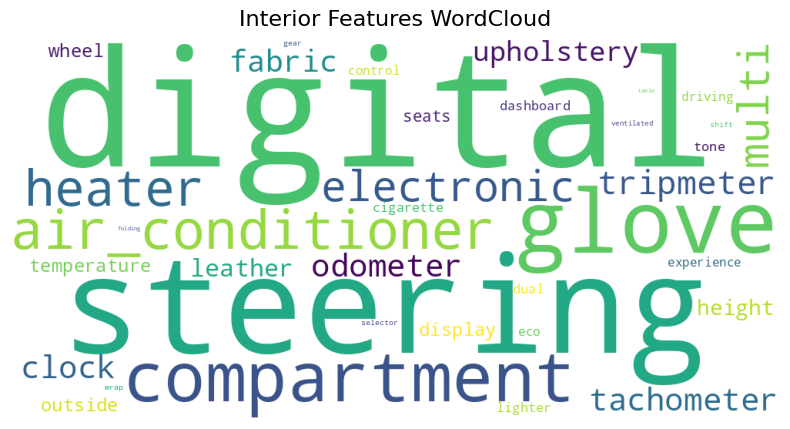

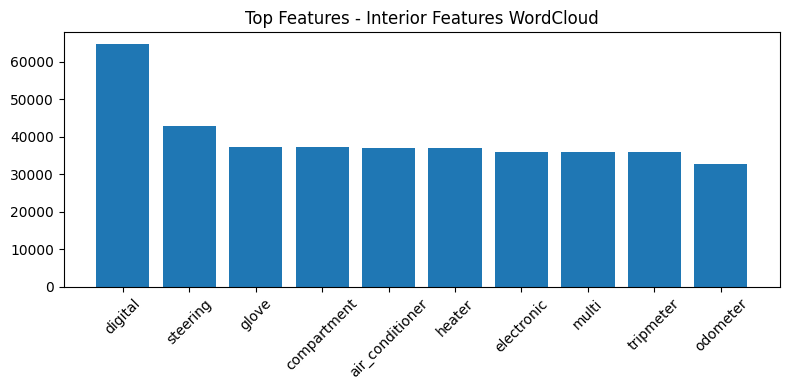

In [ ]:
generate_wordcloud(df, 'interior_features', 'Interior Features WordCloud')

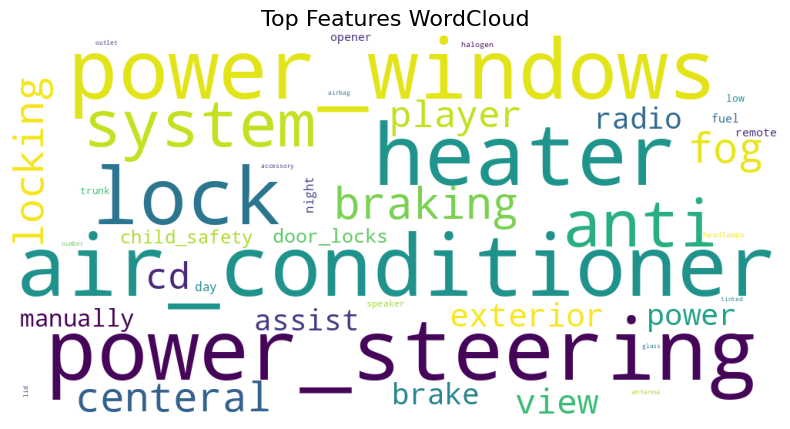

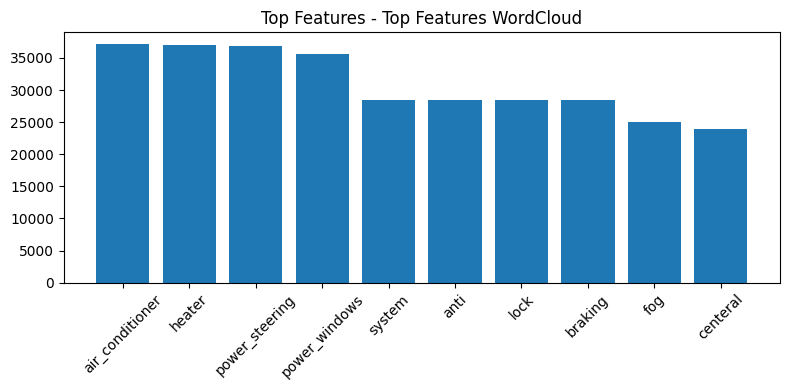

In [ ]:
generate_wordcloud(df, 'top_features', 'Top Features WordCloud')

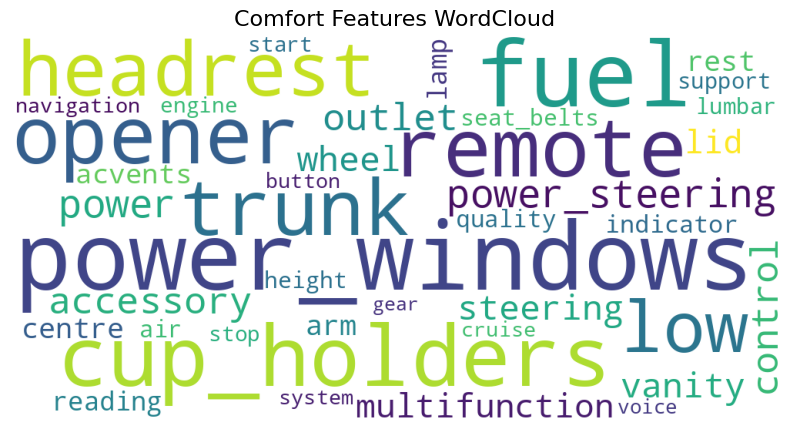

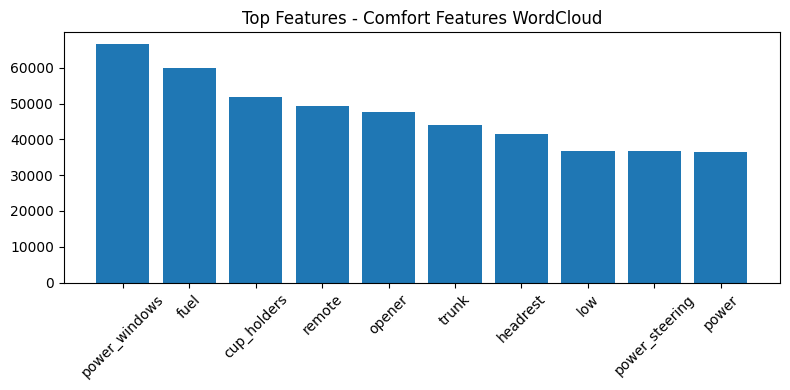

In [ ]:
generate_wordcloud(df, 'comfort_features', 'Comfort Features WordCloud')

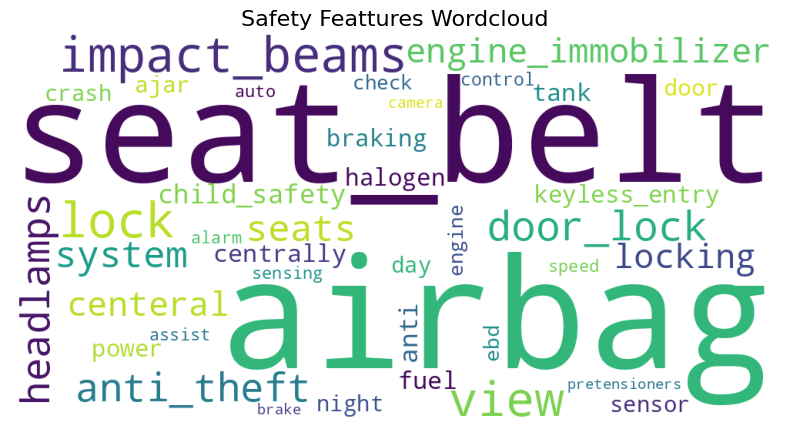

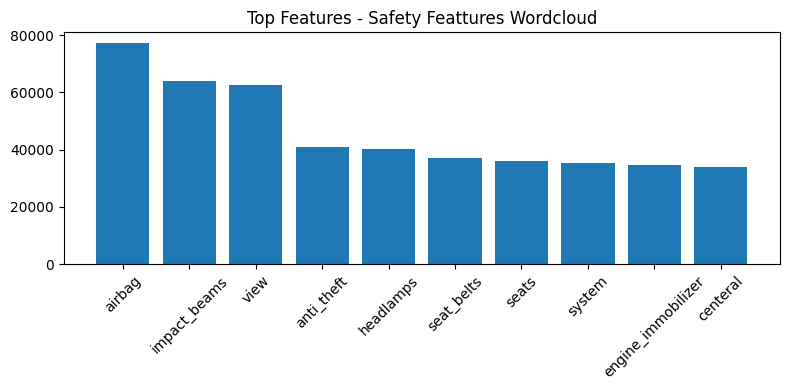

In [ ]:
generate_wordcloud(df, 'safety_features', 'Safety Feattures Wordcloud')

In [ ]:
df['price'] = df['price'].str.replace(',', '', regex=False).astype(float)
state_price = df.groupby('state')['price'].mean().reset_index()

In [ ]:
df['state'] = df['state'].str.lower().str.strip()

In [ ]:
state_mapping = {
    'delhi': 'Delhi',
    'new delhi': 'Delhi',
    'mh': 'Maharashtra',
    'maharashtra': 'Maharashtra',
    'up': 'Uttar Pradesh',
    'uttar pradesh': 'Uttar Pradesh',
    'karnataka': 'Karnataka',
    'tamil nadu': 'Tamil Nadu',
    'haryana': 'Haryana',
    'rajasthan': 'Rajasthan',
    'gujarat': 'Gujarat',
    'jammu & kashmir': 'Jammu and Kashmir',
    'jammu and kashmir': 'Jammu and Kashmir',
    'daman and diu': 'Daman and Diu',
    'daman & diu': 'Daman and Diu',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli',
    'dadra & nagar haveli': 'Dadra and Nagar Haveli',
    'pondicherry': 'Puducherry',
    'odisha': 'Orissa',
    'uttarakhand': 'Uttaranchal',
    'telangana': 'Telangana'
}

In [ ]:
df['state'] = df['state'].map(lambda x: state_mapping.get(x, x.title()))

In [ ]:
geojson_url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson"

In [ ]:
import plotly.express as px

state_price = df.groupby('state')['price'].mean().reset_index()

fig = px.choropleth(
    state_price,
    geojson=geojson_url,
    locations='state',
    featureidkey='properties.NAME_1',  # 🔥 FIXED
    color='price',
    color_continuous_scale='Viridis',
    title='Average Car Price by State'
)

fig.update_traces(
    hovertemplate="<b>%{location}</b><br>Avg Price: ₹%{z:.0f}"
)
fig.update_geos(fitbounds="locations", visible=False)

fig.show()

In [ ]:
import json
import requests

geo = requests.get(geojson_url).json()

# Print the properties of the first feature to inspect available keys
print("First feature properties:", geo['features'][0]['properties'])

# Corrected: Use 'NAME_1' instead of 'NAME'
geo_states = [feature['properties']['NAME_1'] for feature in geo['features']]

print("GeoJSON states:", geo_states)

First feature properties: {'ID_0': 105, 'ISO': 'IND', 'NAME_0': 'India', 'ID_1': 1, 'NAME_1': 'Andaman and Nicobar', 'NL_NAME_1': None, 'VARNAME_1': 'Andaman & Nicobar Islands|Andaman et Nicobar|Iihas de Andama e Nicobar|Inseln Andamanen und Nikobare', 'TYPE_1': 'Union Territor', 'ENGTYPE_1': 'Union Territory'}
GeoJSON states: ['Andaman and Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Orissa', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Tripura', 'Uttar Pradesh', 'Uttaranchal', 'West Bengal']


In [ ]:
print(set(state_price['state']) - set(geo_states))

{'Telangana'}


<Axes: xlabel='body_type'>

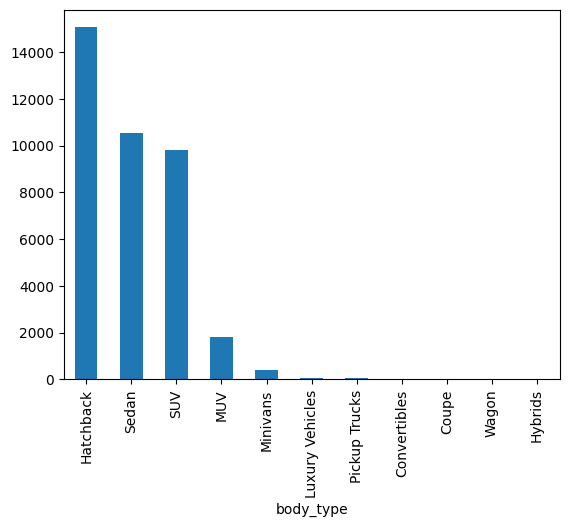

In [ ]:
df['body_type'].value_counts().plot(kind='bar')

<Axes: xlabel='body_type'>

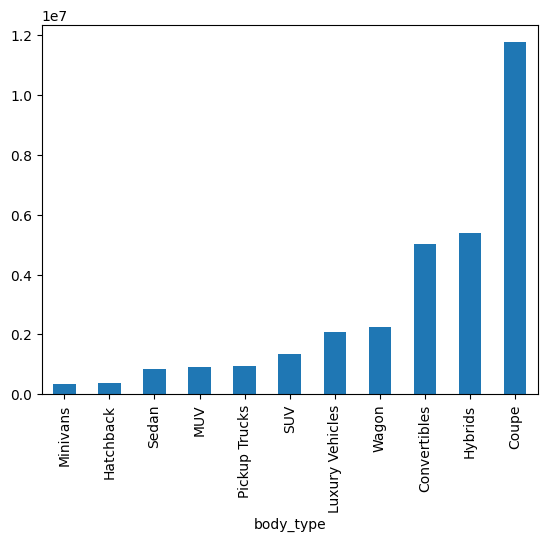

In [ ]:
df.groupby('body_type')['price'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='body_type'>

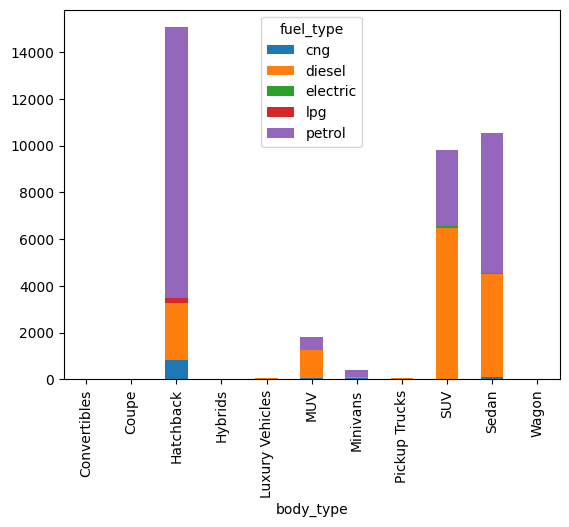

In [ ]:
pd.crosstab(df['body_type'], df['fuel_type']).plot(kind='bar', stacked=True)

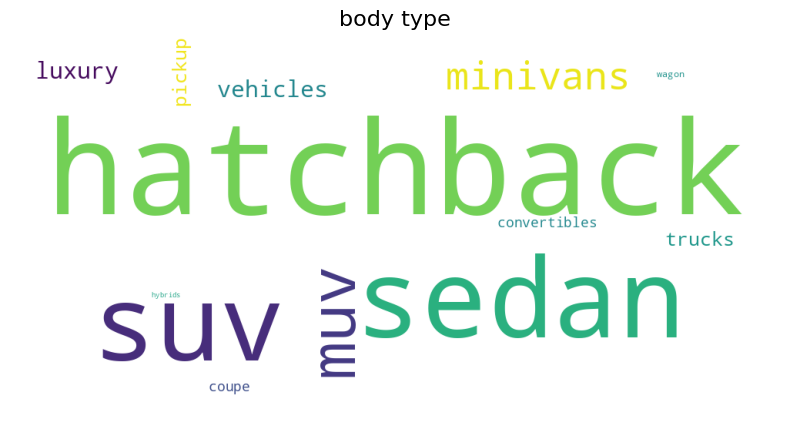

In [ ]:
text = ' '.join(df['body_type'].fillna('').astype(str)).lower()

text = re.sub(r"[^\w\s]", "", text)

text = re.sub(r'\s+', ' ', text).strip()

wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=40,
    colormap='viridis',
    collocations=False
).generate(text)


plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.title('body type', fontsize=16)
plt.axis('off')
plt.show()

In [ ]:
import plotly.express as px

brand = 'maruti'  # example

filtered_df = df[df['brand'] == brand]

state_price = filtered_df.groupby('state')['price'].mean().reset_index()

fig = px.choropleth(
    state_price,
    geojson=geojson_url,
    locations='state',
    featureidkey='properties.NAME_1',
    color='price',
    color_continuous_scale='Viridis',
    title=f'Average Price of {brand} Cars by State'
)
fig.update_traces(
    hovertemplate="<b>%{location}</b><br>Avg Price: ₹%{z:.0f}"
)
fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [ ]:
top_brand = df.groupby(['state', 'brand']).size().reset_index(name='count')

top_brand = top_brand.sort_values(['state', 'count'], ascending=[True, False])
top_brand = top_brand.drop_duplicates('state')

fig = px.choropleth(
    top_brand,
    geojson=geojson_url,
    locations='state',
    featureidkey='properties.NAME_1',
    color='brand',
    title='Most Popular Manufacturer by State'
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [ ]:
df['km_driven'] = df['km_driven'].replace(',', '')

In [ ]:
df['price'] = df['price'].str.replace(',', '').astype('int')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37814 entries, 0 to 37813
Data columns (total 53 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   city                      31963 non-null  object 
 1   myear                     37814 non-null  int64  
 2   body_type                 37795 non-null  object 
 3   threesixty                37814 non-null  bool   
 4   price                     37814 non-null  int64  
 5   emiwidget                 37814 non-null  object 
 6   top_features              37814 non-null  object 
 7   comfort_features          37814 non-null  object 
 8   interior_features         37814 non-null  object 
 9   exterior_features         37814 non-null  object 
 10  safety_features           37814 non-null  object 
 11  color                     37654 non-null  object 
 12  engine_type               36946 non-null  object 
 13  displacement              37761 non-null  float64
 14  max_po

In [ ]:
df = df[df['price'] < 50000000]   # remove crazy high prices
df = df[df['km_driven'] < 300000] # remove unrealistic km

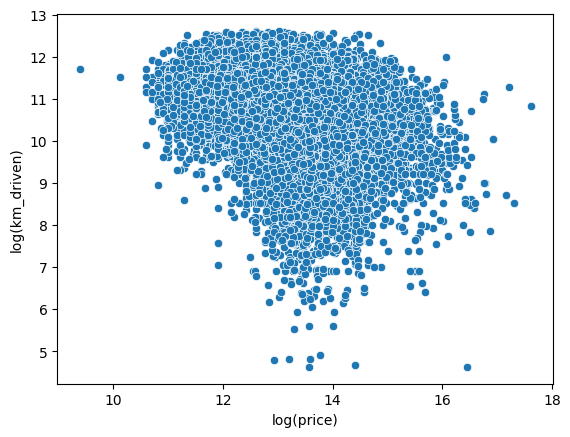

In [ ]:
sns.scatterplot(
    x=np.log1p(df['price']),
    y=np.log1p(df['km_driven'])
)
plt.xlabel("log(price)")
plt.ylabel("log(km_driven)")
plt.show()

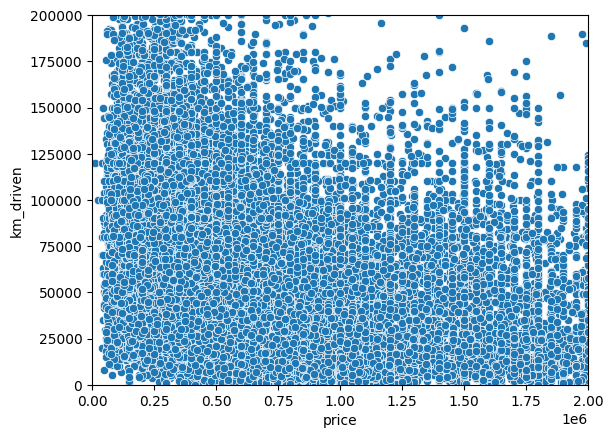

In [ ]:
sns.scatterplot(x=df['price'], y=df['km_driven'])

plt.xlim(0, 2000000)   # focus range
plt.ylim(0, 200000)

plt.show()

<Axes: xlabel='km_driven', ylabel='price'>

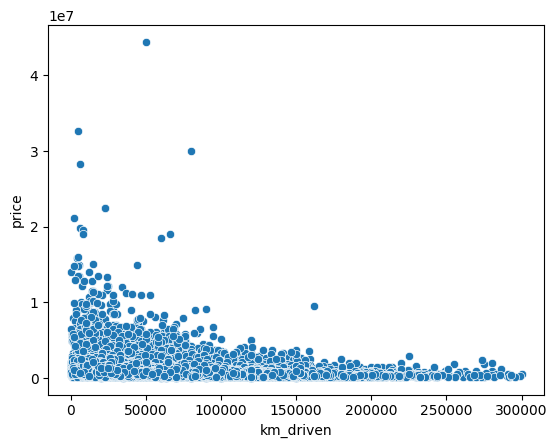

In [ ]:
sns.scatterplot(x=df['km_driven'], y=df['price'])

<Axes: xlabel='km_driven', ylabel='price'>

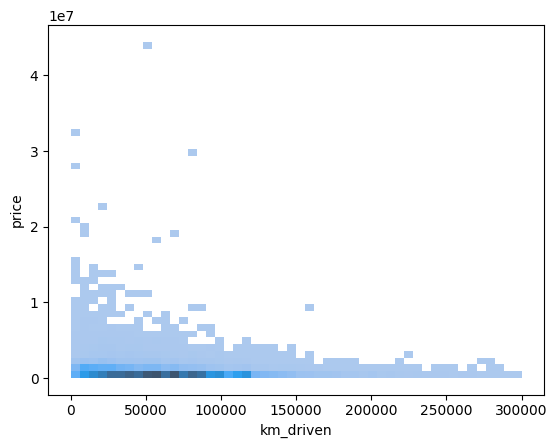

In [ ]:
sns.histplot(x=df['km_driven'], y=df['price'], bins=50)

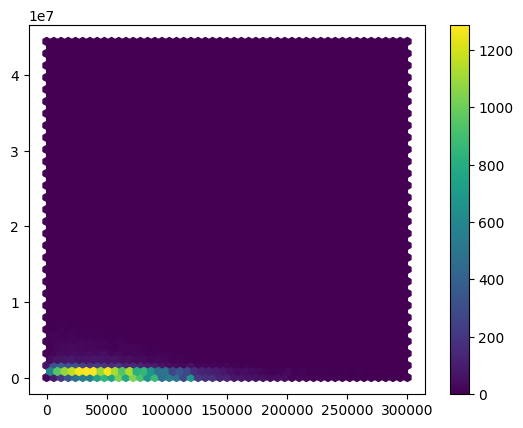

In [ ]:
plt.hexbin(df['km_driven'], df['price'], gridsize=50)
plt.colorbar()

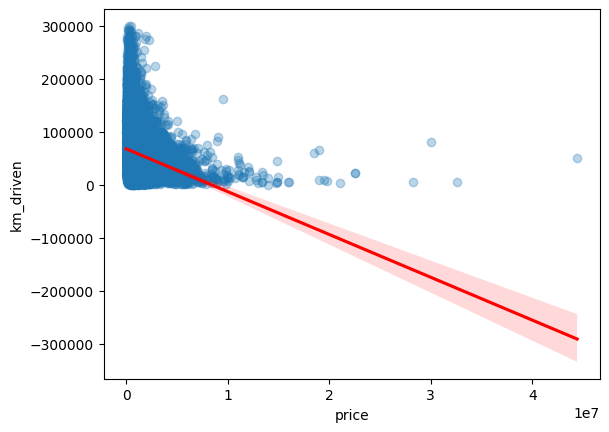

In [ ]:
sns.regplot(
    x=df['price'],
    y=df['km_driven'],
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.show()

In [ ]:
df[['price', 'km_driven']].corr()

,price,km_driven
price,1.00000,-0.20957
km_driven,-0.20957,1.00000


/tmp/ipykernel_12062/711193030.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_bin')['km_driven'].mean().plot()


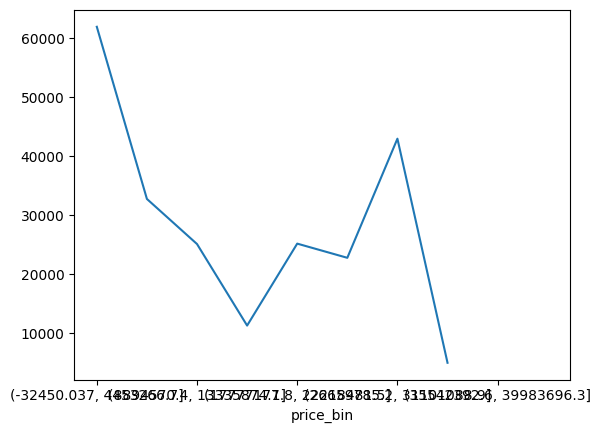

In [ ]:
df['price_bin'] = pd.cut(df['price'], bins=10)

df.groupby('price_bin')['km_driven'].mean().plot()
plt.show()

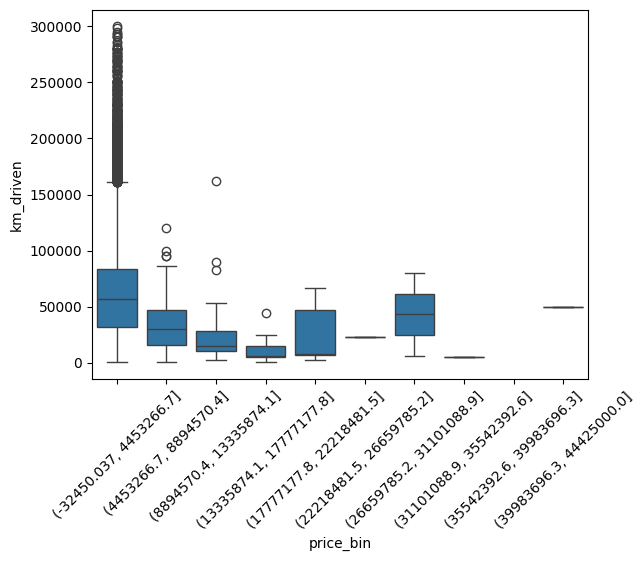

In [ ]:
sns.boxplot(x=df['price_bin'], y=df['km_driven'])
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='price', ylabel='km_driven'>

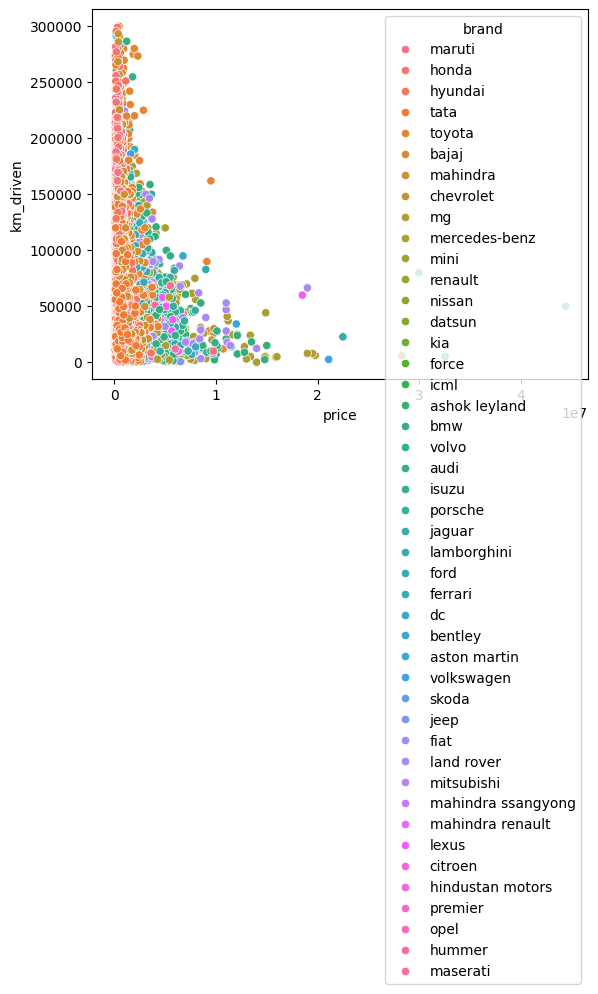

In [ ]:
sns.scatterplot(
    x=df['price'],
    y=df['km_driven'],
    hue=df['brand']
)

<Axes: xlabel='price', ylabel='Count'>

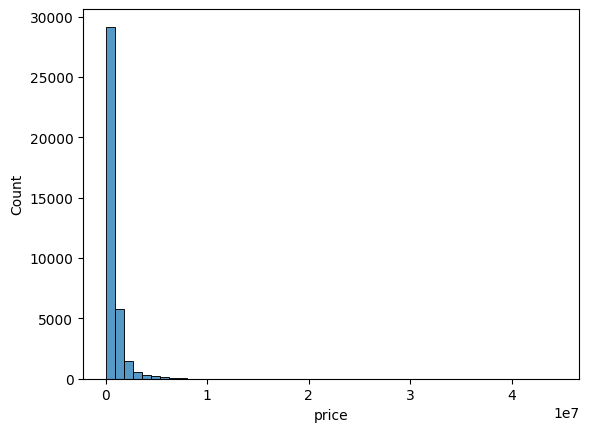

In [ ]:
sns.histplot(df['price'], bins=50)

<Axes: >

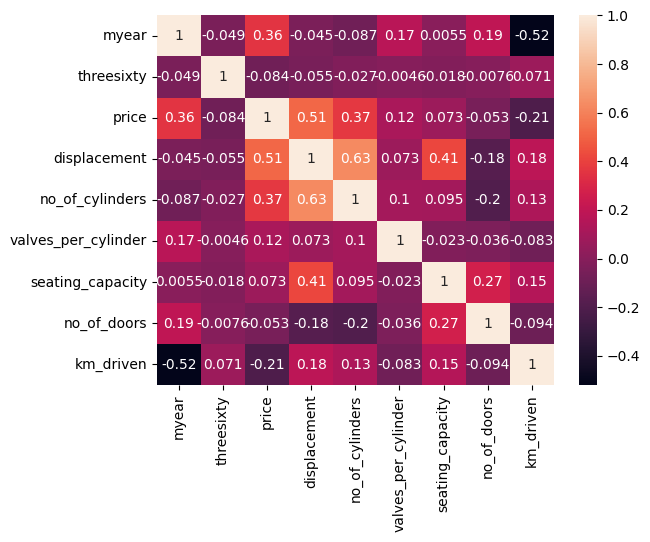

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot = True)

<Axes: xlabel='fuel_type', ylabel='price'>

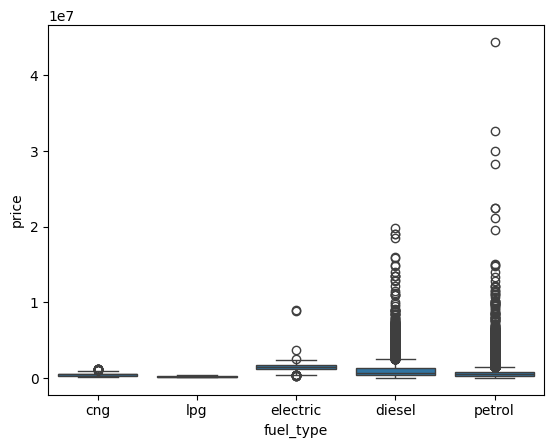

In [ ]:
sns.boxplot(x=df['fuel_type'], y=df['price'])

<Axes: xlabel='myear', ylabel='price'>

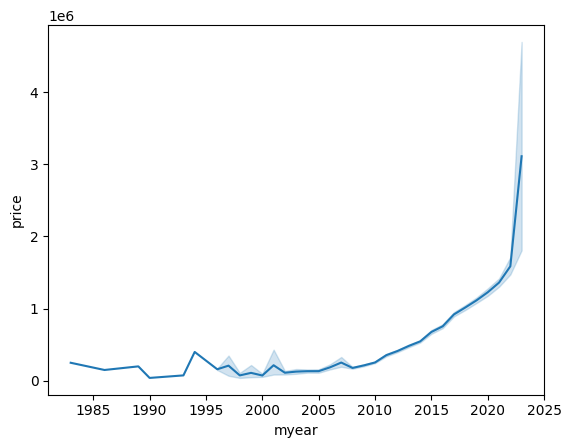

In [ ]:
sns.lineplot(x='myear', y='price', data=df)

<Axes: xlabel='count', ylabel='brand'>

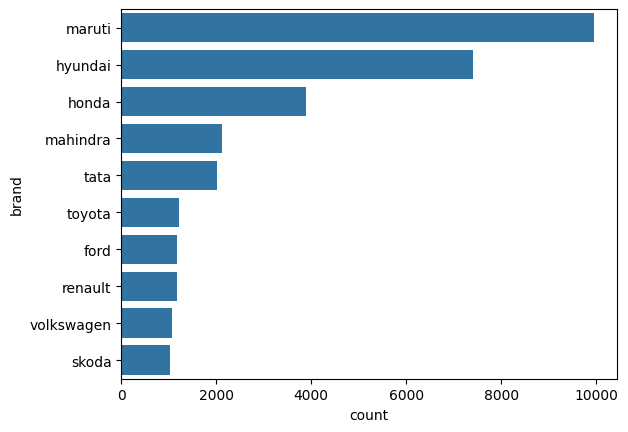

In [ ]:
sns.countplot(y=df['brand'], order=df['brand'].value_counts().head(10).index)

In [ ]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [ ]:
!pip show joblib

Name: joblib
Version: 1.5.3
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: 
Author-email: Gael Varoquaux <gael.varoquaux@normalesup.org>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: hdbscan, imbalanced-learn, librosa, mlxtend, music21, nltk, osqp, pynndescent, scikit-learn, segregation, tobler
